First Five Records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species 

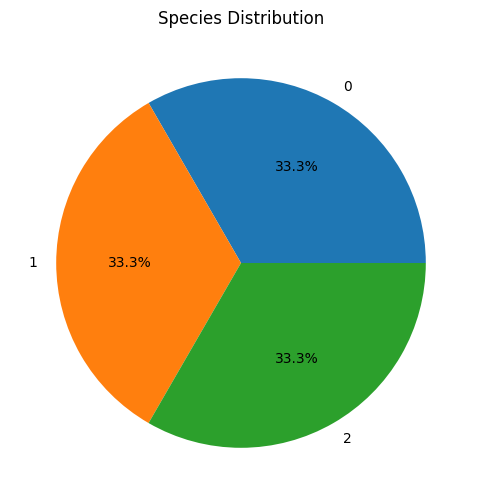

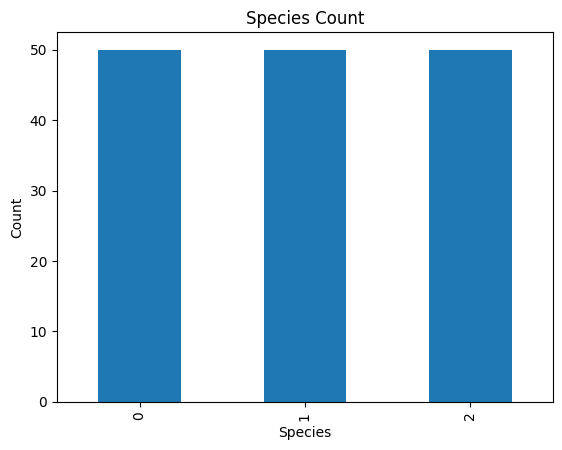

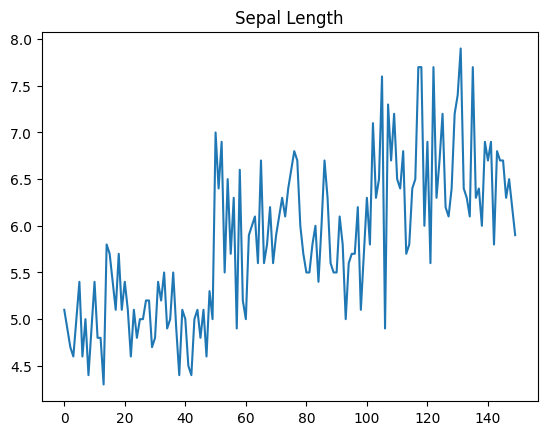


Training Records: 120
Testing Records: 30

Training Accuracy:
0.975

Accuracy:
1.0

Precision:
1.0

Recall:
1.0

F1 Score:
1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Result file saved as iris_result.csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ===================================
# STEP 1: LOAD IRIS DATASET
# ===================================

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["Species"] = iris.target

print("First Five Records:")
print(df.head())

# ===================================
# STEP 2: DATASET INFORMATION
# ===================================

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# ===================================
# STEP 3: VISUALIZATION
# ===================================

# Pie Chart
df["Species"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)
plt.title("Species Distribution")
plt.ylabel("")
plt.show()

# Bar Chart
df["Species"].value_counts().plot(kind="bar")
plt.title("Species Count")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

# Line Chart
df["sepal length (cm)"].plot(kind="line")
plt.title("Sepal Length")
plt.show()

# ===================================
# STEP 4: SPLIT DATASET
# ===================================

X = df.iloc[:, :-1]
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Records:", len(X_train))
print("Testing Records:", len(X_test))

# ===================================
# STEP 5: TRAIN MODEL
# ===================================

model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

# ===================================
# STEP 6: TRAINING RESULT
# ===================================

train_pred = model.predict(X_train)

print("\nTraining Accuracy:")
print(accuracy_score(y_train, train_pred))

# ===================================
# STEP 7: TESTING RESULT
# ===================================

y_pred = model.predict(X_test)

# ===================================
# STEP 8: EVALUATION
# ===================================

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nPrecision:")
print(precision_score(y_test, y_pred, average='weighted'))

print("\nRecall:")
print(recall_score(y_test, y_pred, average='weighted'))

print("\nF1 Score:")
print(f1_score(y_test, y_pred, average='weighted'))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ===================================
# STEP 9: SAVE RESULT FILE
# ===================================

result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.to_csv("iris_result.csv", index=False)

print("\nResult file saved as iris_result.csv")